# Missing Values Pipeline — Ames Housing

This notebook builds a practical missing-values pipeline inspired by the reference notebook and adapted to the Ames Housing dataset.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [12]:
# Load raw data
df_raw = pd.read_csv('../data/raw/AmesHousing.csv')
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [19]:
# Standardize non-standard missing markers
missing_markers = ['?', 'NA', 'N/A', 'None', 'none', 'null', 'NULL', '']

df = df_raw.copy()

before_missing = int(df.isna().sum().sum())

# Count placeholder-like values before replacement
placeholder_hits = 0
for col in df.select_dtypes(include=['object', 'string']).columns:
    s = df[col].astype('string')
    placeholder_hits += int(s.isin(missing_markers).sum())
    placeholder_hits += int(s.str.match(r'^\s*$', na=False).sum())

print('Before marker standardization:')
print('Total missing values:', before_missing)
print('Placeholder-like entries found:', placeholder_hits)

for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].replace(missing_markers, np.nan)
    df[col] = df[col].replace(r'^\s*$', np.nan, regex=True)

after_missing = int(df.isna().sum().sum())
print('After marker standardization:')
print('Total missing values:', after_missing)
print('Delta missing values:', after_missing - before_missing)

if placeholder_hits == 0:
    print('No non-standard missing markers were present in this CSV (expected same total).')

Before marker standardization:
Total missing values: 15749
Placeholder-like entries found: 0
After marker standardization:
Total missing values: 15749
Delta missing values: 0
No non-standard missing markers were present in this CSV (expected same total).


In [14]:
# Missing-value overview
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = (
    pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
    .query('missing_count > 0')
    .sort_values('missing_count', ascending=False)
)

print('Columns with missing values:', missing_summary.shape[0])
missing_summary.head(20)

Columns with missing values: 27


,missing_count,missing_pct
Pool QC,2917,99.56
Misc Feature,2824,96.38
Alley,2732,93.24
Fence,2358,80.48
Mas Vnr Type,1775,60.58
Fireplace Qu,1422,48.53
Lot Frontage,490,16.72
Garage Qual,159,5.43
Garage Cond,159,5.43
Garage Yr Blt,159,5.43


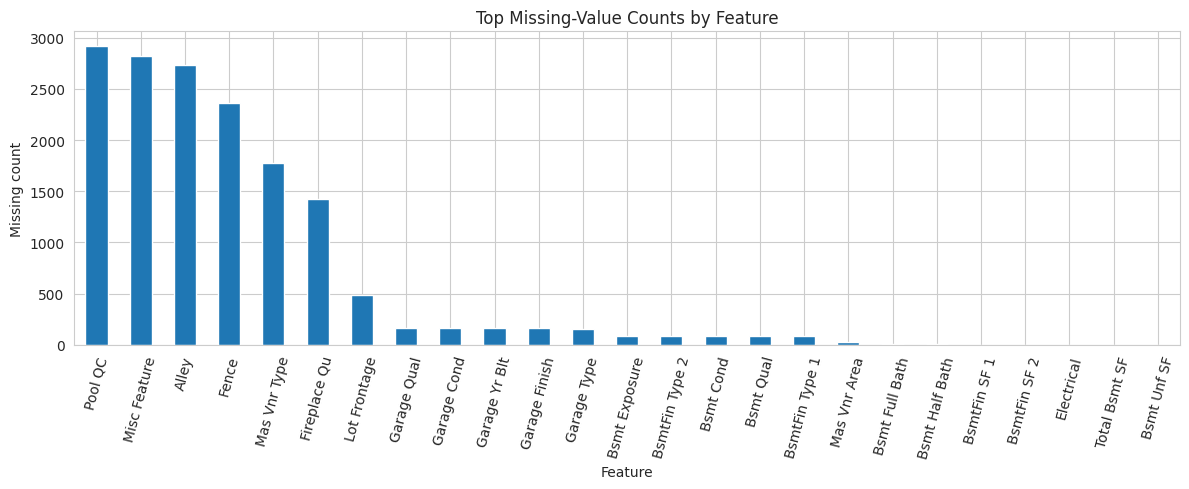

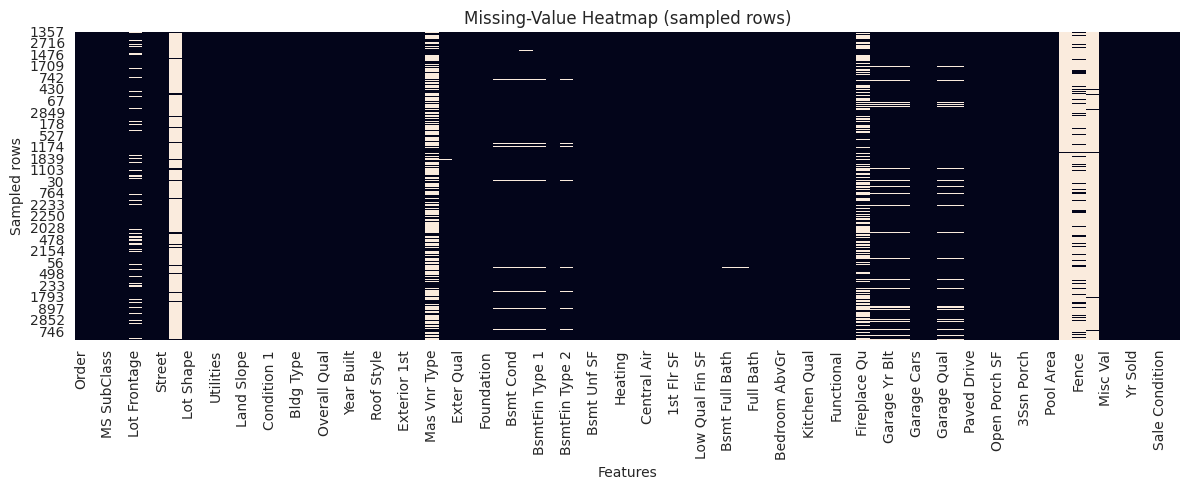

In [15]:
# Visualize missingness (top 25 columns with most missing)
plt.figure(figsize=(12, 5))
missing_summary.head(25)['missing_count'].plot(kind='bar')
plt.title('Top Missing-Value Counts by Feature')
plt.ylabel('Missing count')
plt.xlabel('Feature')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# Missingness heatmap sample (for readability)
plt.figure(figsize=(12, 5))
sns.heatmap(df.sample(min(400, len(df)), random_state=42).isna(), cbar=False)
plt.title('Missing-Value Heatmap (sampled rows)')
plt.xlabel('Features')
plt.ylabel('Sampled rows')
plt.tight_layout()
plt.show()

In [16]:
# Build missing-values preprocessing pipeline
X = df.drop(columns=['SalePrice']) if 'SalePrice' in df.columns else df.copy()
y = df['SalePrice'] if 'SalePrice' in df.columns else None

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True))
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent', add_indicator=True)),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features),
    ],
    remainder='drop'
)

X_processed = preprocessor.fit_transform(X)

print('Original feature matrix shape:', X.shape)
print('Processed feature matrix shape:', X_processed.shape)
print('Any missing left in processed matrix:', np.isnan(X_processed).sum() > 0)

Original feature matrix shape: (2930, 81)
Processed feature matrix shape: (2930, 348)
Any missing left in processed matrix: False


In [17]:
# Optional: view imputed table (without one-hot encoding) for quick inspection
num_imputed = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(X[numeric_features]),
    columns=numeric_features,
    index=X.index
)

cat_imputed = pd.DataFrame(
    SimpleImputer(strategy='most_frequent').fit_transform(X[categorical_features]),
    columns=categorical_features,
    index=X.index
)

X_imputed_view = pd.concat([num_imputed, cat_imputed], axis=1)

print('Missing values after simple imputation view:', int(X_imputed_view.isna().sum().sum()))
X_imputed_view.head()

Missing values after simple imputation view: 0


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin Type 2,Heating,Heating QC,Central Air,Electrical,Kitchen Qual,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
0,1.0,526301100.0,20.0,141.0,31770.0,6.0,5.0,1960.0,1960.0,112.0,639.0,0.0,441.0,1080.0,1656.0,0.0,0.0,1656.0,1.0,0.0,1.0,0.0,3.0,1.0,7.0,2.0,1960.0,2.0,528.0,210.0,62.0,0.0,0.0,0.0,0.0,0.0,5.0,2010.0,RL,Pave,Grvl,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,BrkFace,Plywood,Stone,TA,TA,CBlock,TA,Gd,Gd,BLQ,Unf,GasA,Fa,Y,SBrkr,TA,Typ,Gd,Attchd,Fin,TA,TA,P,Ex,MnPrv,Shed,WD,Normal
1,2.0,526350040.0,20.0,80.0,11622.0,5.0,6.0,1961.0,1961.0,0.0,468.0,144.0,270.0,882.0,896.0,0.0,0.0,896.0,0.0,0.0,1.0,0.0,2.0,1.0,5.0,0.0,1961.0,1.0,730.0,140.0,0.0,0.0,0.0,120.0,0.0,0.0,6.0,2010.0,RH,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,CBlock,TA,TA,No,Rec,LwQ,GasA,TA,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
2,3.0,526351010.0,20.0,81.0,14267.0,6.0,6.0,1958.0,1958.0,108.0,923.0,0.0,406.0,1329.0,1329.0,0.0,0.0,1329.0,0.0,0.0,1.0,1.0,3.0,1.0,6.0,0.0,1958.0,1.0,312.0,393.0,36.0,0.0,0.0,0.0,0.0,12500.0,6.0,2010.0,RL,Pave,Grvl,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,TA,TA,CBlock,TA,TA,No,ALQ,Unf,GasA,TA,Y,SBrkr,Gd,Typ,Gd,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Gar2,WD,Normal
3,4.0,526353030.0,20.0,93.0,11160.0,7.0,5.0,1968.0,1968.0,0.0,1065.0,0.0,1045.0,2110.0,2110.0,0.0,0.0,2110.0,1.0,0.0,2.0,1.0,3.0,1.0,8.0,2.0,1968.0,2.0,522.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2010.0,RL,Pave,Grvl,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,BrkFace,BrkFace,BrkFace,Gd,TA,CBlock,TA,TA,No,ALQ,Unf,GasA,Ex,Y,SBrkr,Ex,Typ,TA,Attchd,Fin,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
4,5.0,527105010.0,60.0,74.0,13830.0,5.0,5.0,1997.0,1998.0,0.0,791.0,0.0,137.0,928.0,928.0,701.0,0.0,1629.0,0.0,0.0,2.0,1.0,3.0,1.0,6.0,1.0,1997.0,2.0,482.0,212.0,34.0,0.0,0.0,0.0,0.0,0.0,3.0,2010.0,RL,Pave,Grvl,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,PConc,Gd,TA,No,GLQ,Unf,GasA,Gd,Y,SBrkr,TA,Typ,TA,Attchd,Fin,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal


In [18]:
# Save imputed dataset to data/processed (overwrite if file already exists)
from pathlib import Path

output_path = Path('../data/processed/AmesHousing_imputed.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)

if y is not None:
    df_imputed_export = X_imputed_view.copy()
    df_imputed_export['SalePrice'] = y.values
else:
    df_imputed_export = X_imputed_view.copy()

file_existed = output_path.exists()
df_imputed_export.to_csv(output_path, index=False, mode='w')

print(f"Saved: {output_path}")
print('Shape:', df_imputed_export.shape)
print('Action:', 'updated existing file' if file_existed else 'created new file')

Saved: ../data/processed/AmesHousing_imputed.csv
Shape: (2930, 82)
Action: updated existing file
